# IMPORT LIBRARY
1. Kode ini merupakan tahap awal program yang berisi import berbagai library yang digunakan untuk pengolahan citra dan klasifikasi menggunakan machine learning.

2. Library os digunakan untuk mengakses, membaca, dan mengelola file maupun folder dataset yang ada di sistem operasi.

3. Library OpenCV digunakan untuk membaca, memproses, serta memanipulasi citra digital seperti resize, grayscale, dan filtering.

4. Matplotlib digunakan untuk menampilkan gambar dan membuat visualisasi data hasil pengolahan.

5. NumPy digunakan untuk melakukan komputasi numerik berbasis array yang mendukung proses pengolahan data citra.

6. Pandas digunakan untuk menyimpan dan mengelola data dalam bentuk tabel agar lebih mudah dianalisis.

7. Fungsi `train_test_split dari Scikit-learn digunakan untuk membagi dataset menjadi data training dan data testing.

8. Fungsi cross_val_predict digunakan untuk melakukan prediksi menggunakan metode cross validation agar hasil evaluasi lebih stabil.

9. Library metrics seperti accuracy_score dan classification_report digunakan untuk menghitung dan menampilkan performa model berdasarkan accuracy, precision, recall, dan F1-score.

10. Fungsi graycomatrix dan graycoprops digunakan untuk menghitung fitur tekstur citra menggunakan metode Gray Level Co-occurrence Matrix (GLCM).

11. Fungsi entropy dari SciPy digunakan untuk mengukur tingkat kerandoman atau kompleksitas pada citra.

12. Algoritma Random Forest digunakan sebagai metode klasifikasi berbasis kumpulan decision tree untuk meningkatkan akurasi prediksi.

13. Algoritma Support Vector Machine (SVM) digunakan untuk mencari hyperplane terbaik yang memisahkan kelas data.

14. Algoritma K-Nearest Neighbor (KNN) digunakan untuk mengklasifikasikan data berdasarkan kedekatan dengan data tetangga terdekat.

15. Metrik evaluasi seperti precision, recall, F1-score, dan confusion matrix digunakan untuk menilai kualitas hasil prediksi model.

16. Confusion matrix digunakan untuk melihat jumlah prediksi benar dan salah dalam bentuk tabel perbandingan antara data aktual dan prediksi.

17. ConfusionMatrixDisplay dan Seaborn digunakan untuk memvisualisasikan hasil evaluasi dalam bentuk grafik atau heatmap agar lebih mudah dipahami.

18. Secara keseluruhan, pipeline ini terdiri dari pembacaan dataset, ekstraksi fitur citra, pelatihan model machine learning, dan evaluasi hasil klasifikasi.

In [ ]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

# FUNGSI RESIZE GAMBAR
Fungsi resize_image(img_path, size) digunakan untuk melakukan tahap preprocessing pada citra dengan cara mengubah ukuran gambar agar seragam sebelum diproses lebih lanjut. Fungsi ini membaca gambar dari path yang diberikan menggunakan OpenCV, kemudian memeriksa apakah gambar berhasil dimuat. Jika gambar valid, maka ukuran gambar akan disesuaikan menggunakan fungsi cv.resize() sesuai parameter ukuran yang ditentukan. Hasil gambar yang sudah diubah ukurannya kemudian dikembalikan untuk digunakan pada tahap berikutnya seperti ekstraksi fitur atau klasifikasi. Jika terjadi kesalahan dalam proses pembacaan atau pengolahan gambar, fungsi akan menangani error tersebut dan mengembalikan nilai None sebagai penanda kegagalan.

Pemilihan preprocessing berupa resize dilakukan karena dalam machine learning berbasis citra, semua input harus memiliki dimensi yang konsisten. Jika ukuran gambar berbeda-beda, maka proses ekstraksi fitur seperti GLCM tidak dapat berjalan dengan baik atau menghasilkan fitur yang tidak sebanding antar data. Dengan melakukan resize, seluruh citra memiliki standar ukuran yang sama sehingga proses perhitungan fitur menjadi lebih stabil, efisien, dan dapat dibandingkan secara adil. Selain itu, resize juga membantu mengurangi kompleksitas komputasi karena gambar yang terlalu besar dapat memperlambat proses pelatihan model tanpa memberikan peningkatan informasi yang signifikan.

In [3]:
def resize_image(img_path, size):
    try:
        img = cv.imread(img_path)
        if img is None:
            raise ValueError(f"Image at {img_path} could not be read.")
        resized_img = cv.resize(img, size)
        return resized_img
    except Exception as e:
        print(f"Error resizing image {img_path}: {e}")
        return None

# LOAD DATASET 
Kode load_dataset(dir) digunakan untuk membaca dan menyiapkan dataset citra yang tersusun dalam folder per kelas. Setiap subfolder dianggap sebagai satu label kelas, sehingga proses labeling dilakukan secara otomatis berdasarkan nama folder. Fungsi ini melakukan iterasi ke setiap kelas dan setiap gambar di dalamnya, kemudian memanggil fungsi resize_image untuk membaca sekaligus menyeragamkan ukuran gambar menjadi 256×256 piksel. Setelah itu, gambar yang berhasil diproses disimpan ke dalam array images, sedangkan labelnya disimpan ke dalam labels. Selain itu, program juga menghitung jumlah data pada setiap kelas menggunakan class_counter untuk melihat distribusi dataset. Setelah semua data terkumpul, fungsi mengembalikan dataset dalam bentuk array serta informasi kelasnya, lalu dilakukan visualisasi distribusi jumlah gambar per kelas menggunakan bar chart.

Loading dataset...
Dataset loaded with 241 images across 2 classes.


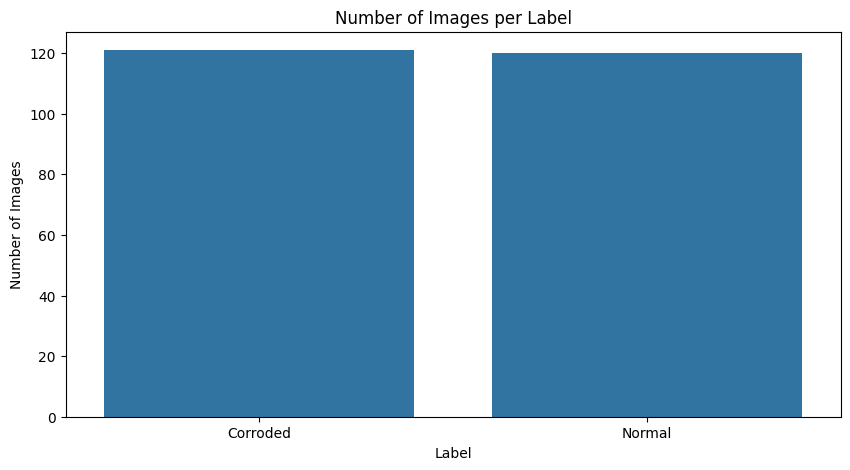

In [16]:
def load_dataset(dir):
    size = (256,256)
    images = []
    labels = []
    class_names = os.listdir(dir)
    class_counter = {class_name: 0 for class_name in class_names}

    for label, class_name in enumerate(class_names):
        class_dir = os.path.join(dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                img_path = os.path.join(class_dir, file_name)
                img = resize_image(img_path, size)
                if img is not None:
                    images.append(img)
                    labels.append(class_name)
                    class_counter[class_name]+=1
    return np.array(images), np.array(labels), class_names, class_counter


print("Loading dataset...")
images, labels, class_names, class_counter = load_dataset('dataset')
print(f"Dataset loaded with {len(images)} images across {len(class_names)} classes.")

# Diagram Dataset
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Number of Images per Label')
plt.xlabel('Label')
plt.ylabel('Number of Images')
plt.savefig('dataset_distribution.png')
plt.show()

# MENAMPILKAN GAMBAR ASLI DARI SETIAP LABEL
Kode show_sample_images(images, labels, class_names) digunakan untuk menampilkan contoh gambar dari setiap kelas dalam dataset sebagai bentuk eksplorasi data. Fungsi ini membuat sebuah figure dengan ukuran tertentu, kemudian melakukan iterasi terhadap setiap nama kelas. Untuk setiap kelas, program mengambil subset gambar yang sesuai dengan label kelas tersebut, lalu memilih salah satu gambar sebagai representasi. Gambar tersebut kemudian ditampilkan menggunakan plt.imshow() setelah dikonversi dari format BGR (OpenCV) ke RGB agar warna tampil dengan benar. Setiap gambar diberi judul sesuai nama kelasnya, dan axis dimatikan agar tampilan lebih rapi. Setelah semua subplot diatur, plt.tight_layout() digunakan untuk merapikan jarak antar gambar, lalu plt.show() menampilkan hasil visualisasi. Fungsi ini kemudian dipanggil untuk menampilkan sampel gambar dari dataset.

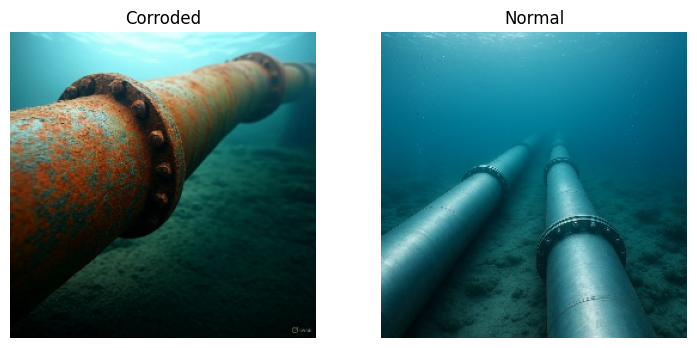

In [ ]:
def show_sample_images(images, labels, class_names):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_images = images[labels == class_name]
        if len(class_images) > 0:
            plt.subplot(3, 4, i + 1)
            plt.imshow(cv.cvtColor(class_images[10], cv.COLOR_BGR2RGB))
            plt.title(class_name)
            plt.axis('off')
    plt.tight_layout()
    plt.show()
show_sample_images(images, labels, class_names)

# PENGUBAHAN SELURUH IMAGE KE GRAYSCALE
Kode dibawah digunakan untuk melakukan preprocessing konversi citra ke grayscale. Semua gambar dalam dataset yang awalnya berformat BGR diubah menjadi citra keabuan menggunakan cv.cvtColor(img, cv.COLOR_BGR2GRAY). Proses ini dilakukan secara berulang untuk setiap gambar, kemudian hasilnya disimpan dalam array img_grey. Setelah itu, gambar grayscale tersebut ditampilkan kembali sebagai sampel untuk memastikan bahwa proses konversi berjalan dengan benar dan setiap kelas masih dapat dikenali secara visual meskipun tanpa informasi warna.

Pemilihan preprocessing berupa konversi grayscale dilakukan karena metode ekstraksi fitur yang digunakan, yaitu GLCM (Gray Level Co-occurrence Matrix), hanya bekerja berdasarkan intensitas keabuan piksel, bukan warna. Artinya, informasi warna pada citra tidak memberikan kontribusi langsung terhadap perhitungan fitur tekstur seperti contrast, homogeneity, correlation, dan energy. Dengan menghilangkan informasi warna, data menjadi lebih sederhana namun tetap mempertahankan informasi penting berupa pola tekstur. Selain itu, penggunaan grayscale juga membuat proses komputasi menjadi lebih efisien karena hanya memproses satu channel dibandingkan tiga channel pada citra RGB/BGR. Hal ini sangat membantu dalam mempercepat proses ekstraksi fitur dan pelatihan model seperti SVM, KNN, dan Random Forest, tanpa mengurangi informasi yang relevan untuk klasifikasi berbasis tekstur.

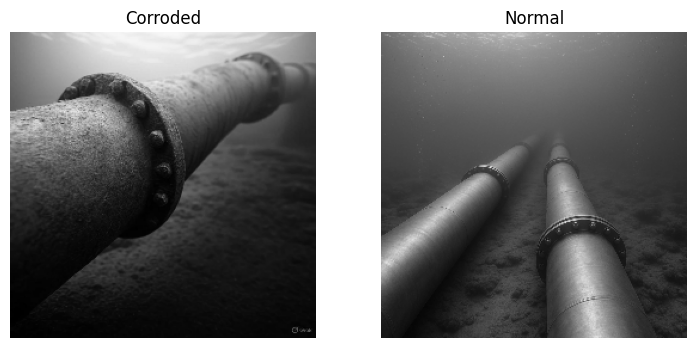

In [19]:
img_grey = []
for img in images:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names)

# MEDIAN FILTER
Kode dibawah melakukan tahap preprocessing lanjutan median filtering pada citra grayscale. Setelah seluruh gambar dikonversi menjadi grayscale, setiap citra kemudian diproses menggunakan fungsi median_filter() dengan ukuran kernel 3x3. Median filter bekerja dengan mengambil nilai piksel di sekitar suatu area, mengurutkan nilainya, lalu mengganti nilai piksel pusat dengan nilai median. Proses ini dilakukan untuk setiap piksel pada seluruh gambar sehingga menghasilkan citra yang lebih halus. Hasil citra yang sudah difilter kemudian disimpan dalam img_median dan ditampilkan kembali untuk memastikan efek filtering berjalan dengan baik.

Penggunaan median filter setelah grayscale dilakukan karena pada tahap ini citra sudah berada dalam bentuk intensitas keabuan, sehingga lebih sesuai untuk proses pengurangan noise berbasis nilai piksel. Median filter dipilih karena sangat efektif dalam menghilangkan noise tipe salt-and-pepper tanpa merusak tepi objek yang sangat penting dalam analisis tekstur seperti GLCM. Hal ini penting karena metode klasifikasi seperti SVM, KNN, dan Random Forest sangat bergantung pada kualitas fitur yang dihasilkan dari citra yang bersih dan konsisten.

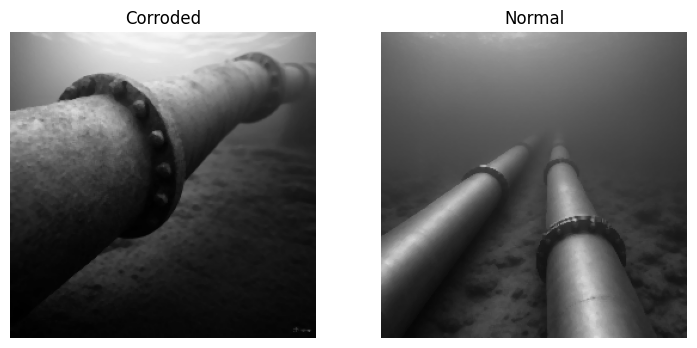

In [43]:
def median_filter(img, size):
    height, width = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode='edge')
    result = np.zeros_like(img, dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]

            values = [0] * (size * size)

            for r in range(size):
                for c in range(size):
                    values[r * size + c] = int(region[r, c])

            n = len(values)

            for x in range(n - 1):
                for y in range(n - x - 1):
                    if values[y] > values[y + 1]:
                        values[y], values[y + 1] = values[y + 1], values[y]

            result[i, j] = values[n // 2]

    return result

img_median = []

for img in img_grey:
    filtered = median_filter(img, 3)
    img_median.append(filtered)

img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names)

# FUNGSI FITUR EKSTRAKSI
Fungsi glcm(image, derajat) digunakan untuk membentuk matriks GLCM berdasarkan hubungan antar piksel dengan jarak 1 pixel dan arah tertentu yang dapat dipilih, yaitu 0°, 45°, 90°, atau 135°. Setiap sudut direpresentasikan dalam bentuk radian sesuai kebutuhan fungsi graycomatrix. Parameter tambahan seperti jumlah level abu-abu (256), symmetric=True, dan normed=True digunakan untuk memastikan matriks bersifat simetris dan ternormalisasi sehingga hasil perhitungan lebih stabil dan dapat dibandingkan antar citra.

Setelah matriks GLCM terbentuk, dilakukan ekstraksi berbagai fitur tekstur menggunakan graycoprops. Fitur yang dihitung antara lain correlation yang mengukur hubungan linear antar piksel, dissimilarity yang menunjukkan perbedaan intensitas, homogeneity yang mengukur tingkat keseragaman, contrast yang menunjukkan variasi intensitas, ASM (Angular Second Moment) yang menggambarkan keteraturan pola, serta energy yang merupakan akar dari ASM dan merepresentasikan tingkat keteraturan tekstur. Selain itu, juga dihitung entropy menggunakan scipy.stats.entropy yang menggambarkan tingkat kerandoman atau kompleksitas pola pada citra.

Seluruh fitur ini digunakan untuk merepresentasikan karakteristik tekstur dari citra dalam bentuk numerik, sehingga dapat digunakan sebagai input pada algoritma klasifikasi seperti Random Forest, SVM, dan KNN.

In [22]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

# EKSTRASI FITUR 
Kode dibawah ini merupakan proses ekstraksi fitur lanjutan berbasis GLCM (Gray Level Co-occurrence Matrix) yang dilakukan setelah tahap preprocessing citra selesai. Citra hasil preprocessing digunakan sebagai input utama, kemudian setiap citra diproses untuk membentuk matriks GLCM pada empat arah berbeda, yaitu 0°, 45°, 90°, dan 135°. Penggunaan beberapa orientasi ini bertujuan untuk menangkap karakteristik tekstur citra dari berbagai sudut sehingga informasi yang diperoleh lebih lengkap dan representatif.

Setelah matriks GLCM untuk setiap arah terbentuk, dilakukan perhitungan berbagai fitur tekstur dari masing-masing matriks tersebut. Fitur yang diekstraksi meliputi contrast yang menggambarkan tingkat variasi intensitas piksel, dissimilarity yang menunjukkan perbedaan antar nilai piksel, homogeneity yang mengukur tingkat keseragaman tekstur, entropy yang merepresentasikan tingkat kompleksitas atau ketidakteraturan pola, ASM (Angular Second Moment) yang menunjukkan keteraturan tekstur, energy yang merupakan bentuk normalisasi dari ASM, serta correlation yang mengukur hubungan linear antar piksel.

Setiap fitur dihitung secara terpisah untuk setiap arah GLCM dan disimpan dalam variabel yang berbeda. Hasil akhir dari proses ini adalah sekumpulan nilai numerik yang merepresentasikan karakteristik tekstur citra secara menyeluruh. Nilai-nilai ini kemudian digunakan sebagai fitur input dalam proses klasifikasi menggunakan algoritma machine learning seperti Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

In [44]:
img_prepros = img_median

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(img_prepros)):
    D0 = glcm(img_prepros[i], 0)
    D45 = glcm(img_prepros[i], 45)
    D90 = glcm(img_prepros[i], 90)
    D135 = glcm(img_prepros[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

# Inisialisasi semua list fitur
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

# Hitung semua fitur untuk setiap sudut
for i in range(len(img_prepros)):
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))
    
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i])) 

# PENGGABUNGAN NILAI EKSTRAKSI FITUR MENJADI DATA TABEL
Kode dibawah merupakan tahap akhir dari proses feature engineering pada sistem klasifikasi citra berbasis GLCM. Setelah seluruh fitur tekstur seperti contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation dihitung dari berbagai arah (0°, 45°, 90°, dan 135°), semua nilai fitur tersebut digabungkan ke dalam sebuah struktur data berbentuk dictionary bernama dataTable. Struktur ini menyatukan seluruh fitur menjadi satu kesatuan data, di mana setiap baris merepresentasikan satu citra dengan berbagai karakteristik teksturnya, serta disertai label kelasnya.

Selanjutnya, data tersebut dikonversi menjadi bentuk tabel menggunakan pandas DataFrame agar lebih mudah dikelola dan dianalisis. Dataset hasil ekstraksi kemudian disimpan ke dalam file CSV sebagai bentuk penyimpanan permanen dari hasil feature extraction. Setelah itu, file CSV tersebut dibaca kembali untuk memastikan data dapat digunakan dalam tahap berikutnya. Kolom Filename dihapus karena tidak berpengaruh terhadap proses klasifikasi, sehingga hanya tersisa fitur dan label. Variabel x digunakan sebagai fitur input , sedangkan y digunakan sebagai target label kelas yang akan diprediksi oleh model machine learning.

In [45]:
dataTable = {'Filename': [f'Image_{i+1}' for i in range(len(img_prepros))],
        'Class': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_process1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_process1.csv')
hasilEkstrak = hasilEkstrak.drop(columns=['Filename'])
x = hasilEkstrak.drop(columns=['Class'])
y = hasilEkstrak['Class']  

# PENGGUNAAN FITUR KORELASI
Kode dibawah digunakan untuk menganalisis hubungan antar fitur hasil ekstraksi GLCM dengan menghitung matriks korelasi menggunakan x.corr(). Matriks ini menunjukkan tingkat hubungan linear antar fitur dalam dataset.

Hasil korelasi kemudian divisualisasikan menggunakan heatmap Seaborn agar lebih mudah dipahami, dengan nilai korelasi ditampilkan pada setiap sel. Visualisasi ini juga disimpan sebagai gambar untuk dokumentasi. Secara keseluruhan, tahap ini bertujuan untuk melihat keterkaitan antar fitur dan mendeteksi kemungkinan adanya fitur yang saling berkorelasi tinggi sebelum masuk ke proses klasifikasi.

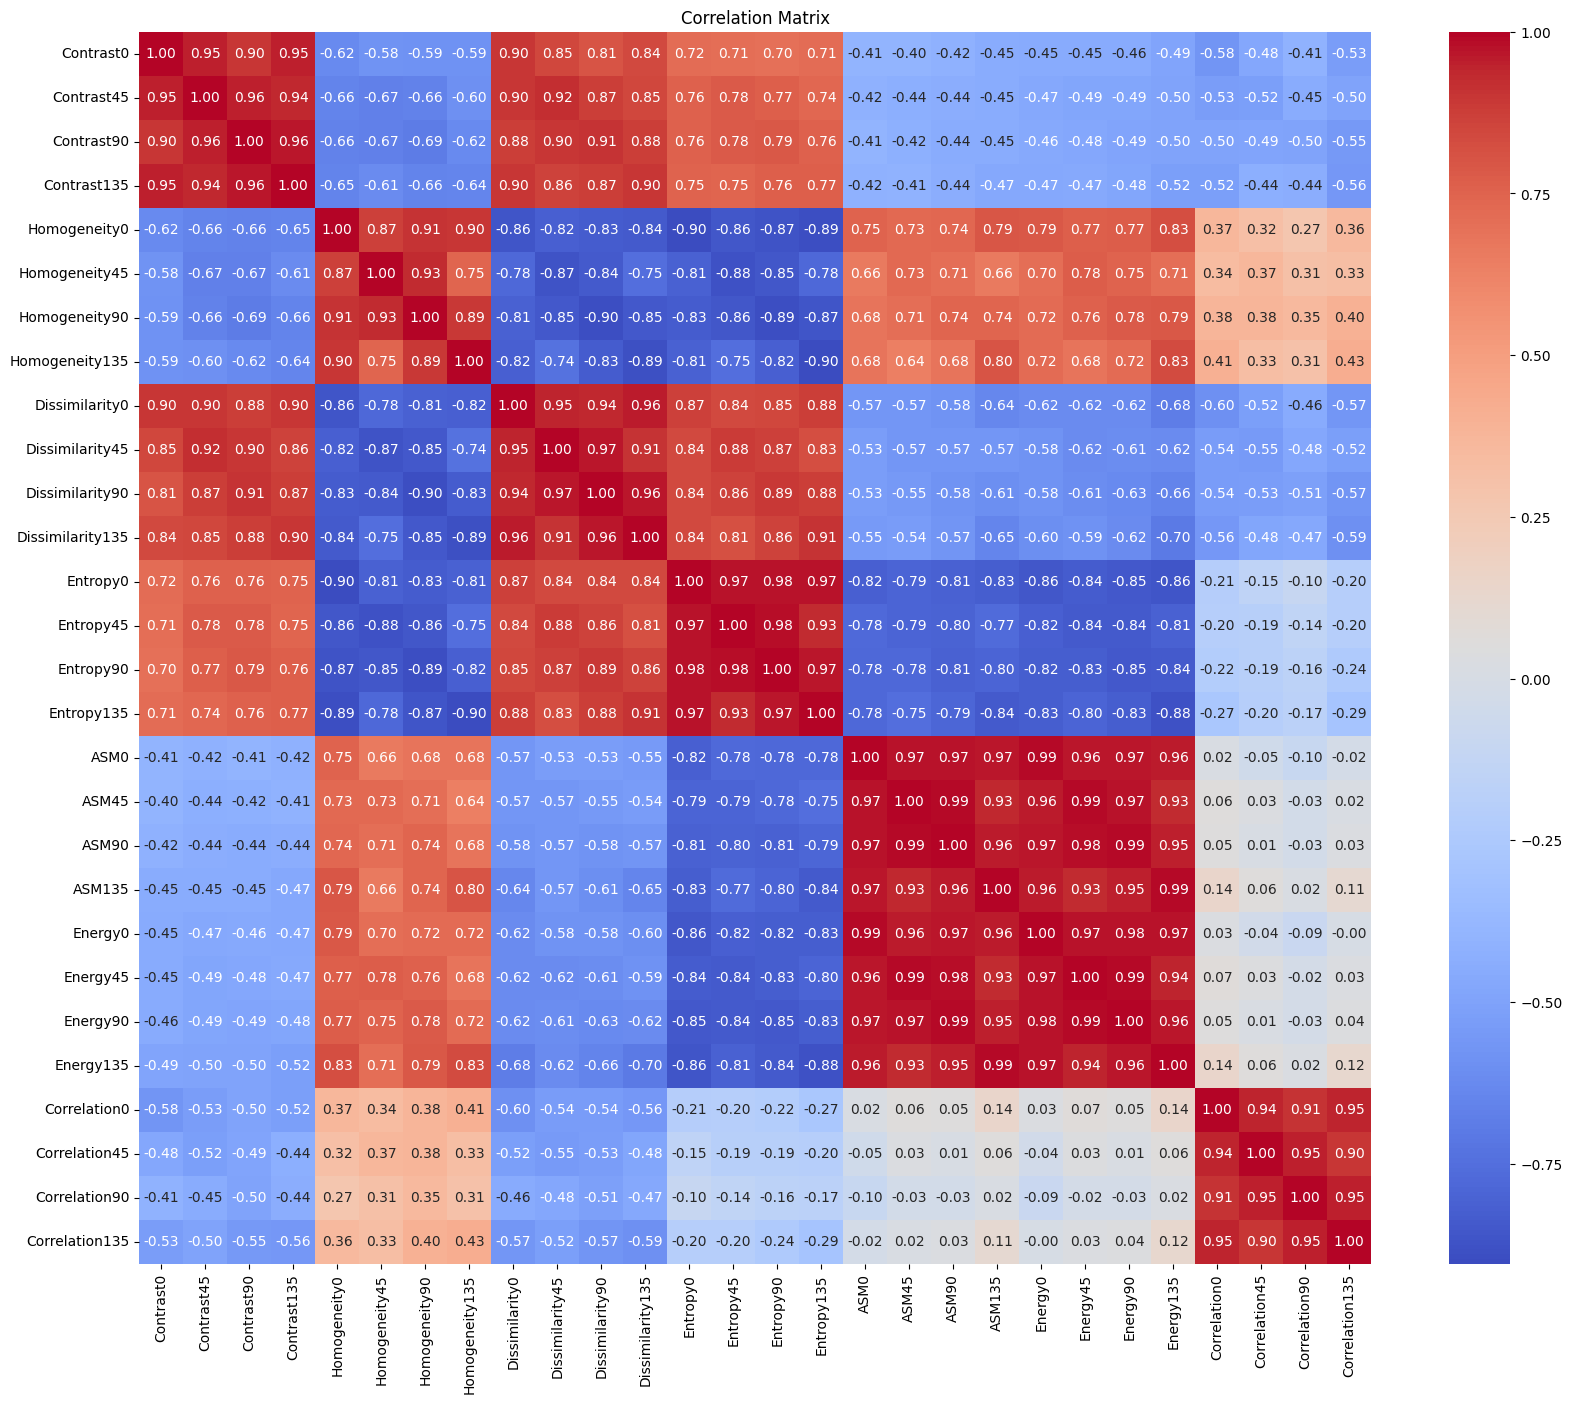

In [ ]:
correlation_matrix = x.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix_process1.png')
plt.show()

# Analisis Correlation Matrix Fitur GLCM
Berdasarkan correlation matrix yang ditampilkan, terlihat bahwa fitur-fitur GLCM yang diekstraksi dari berbagai sudut (0°, 45°, 90°, 135°) menunjukkan korelasi yang sangat tinggi satu sama lain dalam kelompok fitur yang sama. Fitur seperti Contrast, Dissimilarity, Entropy, ASM, Energy, dan Homogeneity memiliki nilai korelasi antar sudut berkisar antara 0.90 hingga 1.00, yang mengindikasikan bahwa informasi yang dibawa oleh setiap sudut pada fitur yang sama hampir identik atau sangat redundan.
Terdapat pula pola korelasi negatif yang kuat antara beberapa kelompok fitur. Entropy dan Dissimilarity berkorelasi negatif kuat terhadap Homogeneity, ASM, dan Energy dengan nilai sekitar -0.82 hingga -0.90. Hal ini secara teoritis sangat masuk akal, karena semakin tinggi ketidakteraturan atau kompleksitas tekstur suatu gambar (tercermin dari nilai Entropy dan Dissimilarity yang tinggi), maka tingkat keseragaman dan keteraturannya (Homogeneity dan Energy) akan semakin rendah.

Hubungan antara fitur ASM dan Energy yang memiliki korelasi mendekati 1.00 di semua sudut, menjadikan keduanya hampir duplikat secara matematis sehingga cukup digunakan salah satunya saja. Sebaliknya, fitur Correlation justru menunjukkan korelasi yang rendah terhadap hampir semua fitur lainnya (mendekati 0.00 hingga 0.14 terhadap ASM/Energy), yang berarti fitur ini membawa informasi yang unik dan tidak tumpang tindih dengan fitur lain.

# MEMBAGI DATA TRAINING DAN TEST
Kode dibawah digunakan untuk melakukan pembagian dataset menjadi data latih (training) dan data uji (testing) menggunakan fungsi train_test_split dari Scikit-learn. Dataset fitur x dan label y dibagi dengan proporsi 80% untuk data training dan 20% untuk data testing (test_size=0.2). Parameter random_state=42 digunakan agar hasil pembagian data selalu konsisten setiap kali program dijalankan.

Setelah proses pembagian, dilakukan pengecekan ukuran masing-masing data menggunakan .shape untuk memastikan jumlah data pada training dan testing sudah sesuai. Data training digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk menguji performa model terhadap data yang belum pernah dilihat sebelumnya. Secara keseluruhan, tahap ini bertujuan untuk memisahkan data agar evaluasi model dapat dilakukan secara objektif dan tidak terjadi overfitting.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("X Train :", x_train.shape)
print("X Test  :", x_test.shape)
print("Y Train :", y_train.shape)
print("Y Test  :", y_test.shape)

X Train : (192, 28)
X Test  : (49, 28)
Y Train : (192,)
Y Test  : (49,)


# NORMALISASI DATA DENGAN MEAN STD
Kode dibawah digunakan untuk melakukan normalisasi data menggunakan metode mean–standard deviation. Fungsi normalize_data(data) menghitung nilai rata-rata (mean) dan standar deviasi (std) dari setiap fitur pada data, kemudian mengubah nilai data dengan rumus (x−mean)/std sehingga setiap fitur memiliki skala yang seragam.

Setelah fungsi dibuat, normalisasi diterapkan pada data latih (x_train) dan data uji (x_test) untuk memastikan seluruh fitur berada pada skala yang sama sebelum digunakan dalam proses klasifikasi. Hal ini penting karena algoritma seperti SVM dan KNN sangat sensitif terhadap perbedaan skala fitur. Secara keseluruhan, tahap ini bertujuan untuk meningkatkan stabilitas dan performa model dalam proses pelatihan dan prediksi.

In [36]:
# normalisasi mean std
def normalize_data(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    normalized_data = (data - mean) / std
    return normalized_data
x_train = normalize_data(x_train)   
x_test = normalize_data(x_test)

# MODELING
Kode dibawah digunakan untuk menyiapkan fungsi evaluasi model serta mendefinisikan algoritma klasifikasi yang akan digunakan. Fungsi generateClassificationReport(y_true, y_pred) berfungsi untuk menampilkan hasil evaluasi model dalam bentuk classification_report yang berisi precision, recall, dan f1-score, serta menampilkan confusion_matrix untuk melihat jumlah prediksi benar dan salah. Selain itu, fungsi ini juga menghitung akurasi model menggunakan accuracy_score sebagai ukuran performa keseluruhan.

Setelah itu, didefinisikan tiga algoritma machine learning yang akan digunakan untuk klasifikasi, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN). Random Forest dibuat dengan jumlah pohon sebanyak 5 (n_estimators=5) dan random state 42 untuk konsistensi hasil. SVM menggunakan kernel RBF yang umum digunakan untuk data non-linear, sedangkan KNN menggunakan jumlah tetangga sebanyak 5 (n_neighbors=5)

In [37]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# TRAIN RANDOM FOREST
Kode dibawah digunakan untuk melatih dan mengevaluasi model Random Forest Classifier pada dataset hasil ekstraksi fitur. Pertama, model Random Forest dilatih menggunakan data training (x_train dan y_train) dengan metode fit, sehingga model belajar mengenali pola dari fitur yang tersedia.

Setelah proses pelatihan, model diuji menggunakan dua pendekatan evaluasi. Pertama, dilakukan prediksi pada data training untuk melihat seberapa baik model mempelajari data yang sudah pernah dilihat. Kedua, dilakukan prediksi pada data testing untuk mengukur kemampuan model dalam menggeneralisasi data baru yang belum pernah dilihat sebelumnya.

Hasil prediksi pada masing-masing dataset kemudian dievaluasi menggunakan fungsi generateClassificationReport, yang menampilkan classification report, confusion matrix, dan nilai akurasi.

In [38]:
# Train Random Forest Classifier
rf.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(x_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    Corroded       0.99      0.98      0.98        95
      Normal       0.98      0.99      0.98        97

    accuracy                           0.98       192
   macro avg       0.98      0.98      0.98       192
weighted avg       0.98      0.98      0.98       192

[[93  2]
 [ 1 96]]
Accuracy: 0.984375

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.80      0.77      0.78        26
      Normal       0.75      0.78      0.77        23

    accuracy                           0.78        49
   macro avg       0.78      0.78      0.78        49
weighted avg       0.78      0.78      0.78        49

[[20  6]
 [ 5 18]]
Accuracy: 0.7755102040816326


# TRAIN SVM
Kode dibawah digunakan untuk melatih dan mengevaluasi model Support Vector Machine (SVM) pada dataset hasil ekstraksi fitur. Model SVM dilatih menggunakan data training (x_train dan y_train) dengan metode fit, sehingga model dapat mempelajari pola pemisahan antar kelas berdasarkan fitur yang tersedia.

Setelah proses pelatihan, model kemudian diuji menggunakan dua skenario, yaitu pada data training dan data testing. Pengujian pada data training dilakukan untuk melihat seberapa baik model mempelajari data yang sudah dikenali, sedangkan pengujian pada data testing digunakan untuk mengukur kemampuan model dalam menggeneralisasi data baru yang belum pernah dilihat sebelumnya.

Hasil prediksi dari kedua pengujian tersebut dievaluasi menggunakan fungsi generateClassificationReport, yang menampilkan classification report, confusion matrix, serta nilai akurasi.

In [39]:
# Train SVM Classifier
svm.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(x_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.93      0.86      0.90        95
      Normal       0.88      0.94      0.91        97

    accuracy                           0.90       192
   macro avg       0.90      0.90      0.90       192
weighted avg       0.90      0.90      0.90       192

[[82 13]
 [ 6 91]]
Accuracy: 0.9010416666666666

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.87      0.77      0.82        26
      Normal       0.77      0.87      0.82        23

    accuracy                           0.82        49
   macro avg       0.82      0.82      0.82        49
weighted avg       0.82      0.82      0.82        49

[[20  6]
 [ 3 20]]
Accuracy: 0.8163265306122449


# TRAIN KNN
Kode dibawah digunakan untuk melatih dan mengevaluasi model K-Nearest Neighbor (KNN) pada dataset hasil ekstraksi fitur. Model KNN dilatih menggunakan data training (x_train dan y_train) dengan metode fit, sehingga model dapat menyimpan data sebagai acuan untuk menentukan kelas berdasarkan kedekatan jarak antar fitur.

Setelah proses pelatihan, model kemudian diuji pada dua kondisi, yaitu data training dan data testing. Pengujian pada data training dilakukan untuk melihat kemampuan model dalam mengenali data yang sudah dipelajari, sedangkan pengujian pada data testing digunakan untuk mengukur kemampuan generalisasi model terhadap data baru yang belum pernah dilihat sebelumnya.

Hasil prediksi pada kedua pengujian tersebut dievaluasi menggunakan fungsi generateClassificationReport, yang menampilkan classification report, confusion matrix, serta nilai akurasi.

In [40]:
# Train KNN Classifier
knn.fit(x_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(x_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(x_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    Corroded       0.92      0.86      0.89        95
      Normal       0.87      0.93      0.90        97

    accuracy                           0.90       192
   macro avg       0.90      0.90      0.90       192
weighted avg       0.90      0.90      0.90       192

[[82 13]
 [ 7 90]]
Accuracy: 0.8958333333333334

------Testing Set------
              precision    recall  f1-score   support

    Corroded       0.83      0.77      0.80        26
      Normal       0.76      0.83      0.79        23

    accuracy                           0.80        49
   macro avg       0.80      0.80      0.80        49
weighted avg       0.80      0.80      0.80        49

[[20  6]
 [ 4 19]]
Accuracy: 0.7959183673469388


# CONFUSION MATRIX RANDOM FOREST, SVM, DAN KNN
Kode dibawah digunakan untuk memvisualisasikan hasil evaluasi model klasifikasi dalam bentuk confusion matrix. Fungsi plot_confusion_matrix(y_true, y_pred, title) menerima label asli (y_true) dan hasil prediksi model (y_pred), kemudian menghitung confusion matrix menggunakan confusion_matrix.

Hasil confusion matrix tersebut ditampilkan dalam bentuk visual menggunakan ConfusionMatrixDisplay dengan warna Blues agar lebih mudah dibaca. Judul grafik disesuaikan berdasarkan model yang sedang dievaluasi, seperti Random Forest, SVM, atau KNN.

Selanjutnya, fungsi ini dipanggil untuk masing-masing model pada data testing (x_test), sehingga diperoleh visualisasi performa setiap algoritma dalam mengklasifikasikan data.

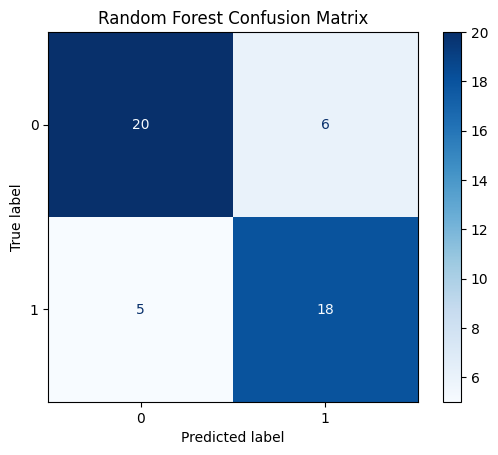

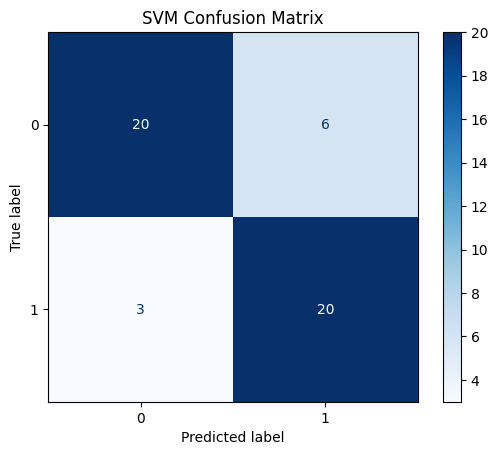

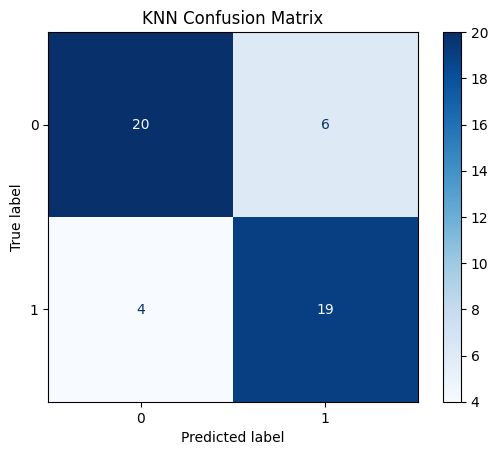

In [41]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(x_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(x_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(x_test), "KNN Confusion Matrix")

# ANALISIS CONFUSION MATRIX 
### 1. RANDOM FOREST
Model Random Forest berhasil mengklasifikasikan 20 data kelas 0 dengan benar dan 18 data kelas 1 dengan benar. Namun terdapat 6 False Positive (kelas 0 diprediksi sebagai kelas 1) dan 5 False Negative (kelas 1 diprediksi sebagai kelas 0), sehingga total kesalahan klasifikasi sebanyak 11 data.
### 2. SVM
SVM menunjukkan performa terbaik dengan berhasil mengklasifikasikan 20 data kelas 0 dan 20 data kelas 1 dengan benar. Kesalahan hanya terjadi pada 6 False Positive dan 3 False Negative, sehingga total kesalahan hanya 9 data.
### 3. KNN
KNN berada di posisi tengah dengan mengklasifikasikan 20 data kelas 0 dan 19 data kelas 1 dengan benar. Terdapat 6 False Positive dan 4 False Negative, dengan total kesalahan sebanyak 10 data.

# TABEL PERBANDINGAN MODEL
Kode dibawah digunakan untuk membuat tabel perbandingan performa beberapa model klasifikasi, yaitu Random Forest, SVM, dan KNN berdasarkan hasil prediksi pada data testing. Fungsi display_model_comparison menghitung beberapa metrik evaluasi utama, yaitu accuracy, precision, recall, dan F1-score untuk setiap model.

Untuk metrik precision, recall, dan F1-score digunakan parameter average='weighted' agar perhitungan mempertimbangkan distribusi seluruh kelas dalam dataset. Hasil perhitungan setiap metrik kemudian disimpan dalam bentuk dictionary dan dikonversi menjadi DataFrame agar dapat ditampilkan dalam bentuk tabel yang lebih rapi dan mudah dibandingkan.

Selanjutnya, masing-masing model melakukan prediksi pada data testing (x_test), kemudian hasilnya dibandingkan menggunakan fungsi tersebut.

In [42]:
#Tabel Perbandingan
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):
    
    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score
    }

    comparison_data = {}

    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                scores = metric_func(y_true, pred, average='weighted')
                comparison_data[name][metric_name] = scores
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)
# Display model comparison
rf_pred = rf.predict(x_test)
svm_pred = svm.predict(x_test)
knn_pred = knn.predict(x_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.775510,0.776531,0.775510,0.775698
SVM,0.816327,0.822469,0.816327,0.816327
KNN,0.795918,0.798912,0.795918,0.796088


# ANALISIS TABEL PERBANDINGAN MODEL
### 1. Random Forest 
Mencatat performa terendah dengan akurasi 77.55% dan F1-Score 0.7757. Meskipun nilai precision-nya sedikit lebih tinggi dari accuracy dan recall, perbedaannya sangat kecil, menunjukkan model ini cukup seimbang namun kurang optimal dalam memisahkan kedua kelas.
### 2. SVM 
Tampil sebagai model terbaik dengan akurasi tertinggi 81.63% dan precision 82.25%. Nilai precision yang lebih tinggi dari recall menunjukkan bahwa SVM lebih berhati-hati dalam memprediksi kelas positif sehingga lebih sedikit menghasilkan False Positive. F1-Score sebesar 0.8163 mencerminkan keseimbangan yang baik antara precision dan recall.
### 3. KNN 
Berada di posisi kedua dengan akurasi 79.59% dan F1-Score 0.7961. Performa KNN konsisten di semua metrik dan berada tepat di antara Random Forest dan SVM, menunjukkan kemampuan generalisasi yang cukup baik namun belum optimal.

# KESIMPULAN
SVM adalah model yang paling direkomendasikan untuk dataset ini karena unggul di semua metrik evaluasi. Hal ini kemungkinan disebabkan oleh kemampuan SVM dalam menemukan hyperplane optimal untuk memisahkan kelas, yang cocok dengan karakteristik fitur GLCM yang memiliki banyak korelasi tinggi antar fitur. Ke depannya, performa ketiga model berpotensi ditingkatkan lebih lanjut melalui seleksi fitur untuk mengurangi redundansi, tuning hyperparameter, serta augmentasi data untuk mengatasi sampel yang ambigu di perbatasan kelas.